In [7]:
import os, sys
import h5py
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as sc

HOME = os.getenv('HOME')
ROOT = os.path.abspath(os.pardir)
print(ROOT)
sys.path.append(ROOT+'/scripts')

import sdds
import teufel

mec2 = sc.m_e*sc.c**2 / sc.e

/home/lehnertu/Programming/TEUFEL


In [41]:
!ls -l

insgesamt 11832
-rw-rw-r-- 1 lehnertu lehnertu    50048 Apr 25 13:17 chicane_beam_final.h5
-rw-rw-r-- 1 lehnertu lehnertu   631700 Apr 25 13:17 chicane_beam.sdds
-rw-rw-r-- 1 lehnertu lehnertu    50048 Apr 25 13:17 chicane_beam_start.h5
-rw-rw-r-- 1 lehnertu lehnertu   260336 Apr 25 13:17 Chicane_testing.ipynb
-rw-rw-r-- 1 lehnertu lehnertu   484731 Apr 24 10:50 CSR2d_testing.ipynb
-rw-rw-r-- 1 lehnertu lehnertu   144171 Apr 24 10:46 CSR_InteractionField.ipynb
-rw-rw-r-- 1 lehnertu lehnertu    18339 Apr 24 10:46 LienardWiechert.ipynb
-rw-rw-r-- 1 lehnertu lehnertu 10455870 Apr 24 10:46 MIR_superradiance.ipynb


In [51]:
!{ROOT}/build/teufel {ROOT}/examples/chicane.xml


 TEUFEL 0.11.01

 THz-Emission from Undulators and Free-Electron Lasers


 TEUFEL parallel computing on 1 nodes.

node 0 : fwl57 PID=3546328 total memory 32620 MB using 20 parallel threads
node 0 memory usage : 212.92 MB

reading XML input from /home/lehnertu/Programming/TEUFEL/examples/chicane.xml
input parsed without errors
case : Electron beam transport through the TELBE magnetic chicane
by : Ulf Lehnert 23.4.2025

calc : total beam energy [eV] = 2.4e+07
calc : gamma = 46.9668
calc : beta*gamma = 46.9562
calc : B*r [T m] = 0.0800372
calc : nominal current I [A] = 35
calc : magnetic field B [T] = 0.16779
calc : trajectory radius r [m] = 0.477008
calc : deflection angle alpha [deg] = 18.3282
calc : R_56 = 0.131875
calc : tracking length [m] = 2.1
calc : tracking step [m] = 0.001
calc : tracking time step [s] = 3.33564e-12
D1::SoftEdgeDipole
D2::SoftEdgeDipole
D3::SoftEdgeDipole
D4::SoftEdgeDipole

lattice of 4 elements created.


beam of 1 bunches created.
total number of particles :

In [55]:
log_data = teufel.readTeufelBeamLog('chicane_beam.sdds')

In [56]:
log_data.keys()

dict_keys(['x_avg', 'y_avg', 'z_avg', 't', 'x_rms', 'y_rms', 'z_rms', 'bgx_avg', 'bgy_avg', 'bgz_avg', 'gamma', 'delta', 'BF'])

In [57]:
t = np.array(log_data['t'])
x = np.array(log_data['x_avg'])
y = np.array(log_data['y_avg'])
z = np.array(log_data['z_avg'])
x_rms = np.array(log_data['x_rms'])
y_rms = np.array(log_data['y_rms'])
z_rms = np.array(log_data['z_rms'])
bgx = np.array(log_data['bgx_avg'])
bgy = np.array(log_data['bgy_avg'])
bgz = np.array(log_data['bgz_avg'])
gamma = np.array(log_data['gamma'])
delta = np.array(log_data['delta'])
bf = np.array(log_data['BF'])
print(f'{len(t)} data points')

2101 data points


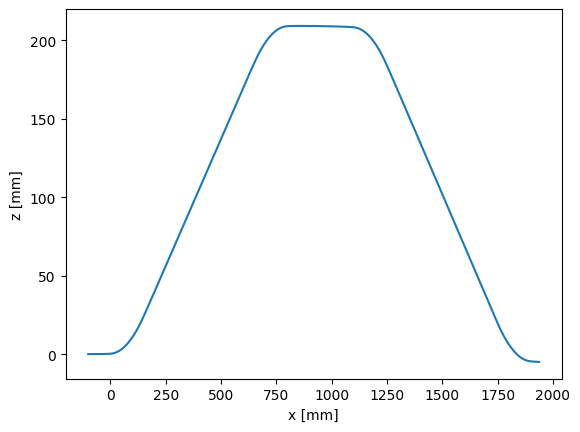

In [58]:
plt.plot(1e3*x, 1e3*z)
plt.xlabel('x [mm]')
plt.ylabel('z [mm]')
plt.show()

### beam transport with 1% energy spread

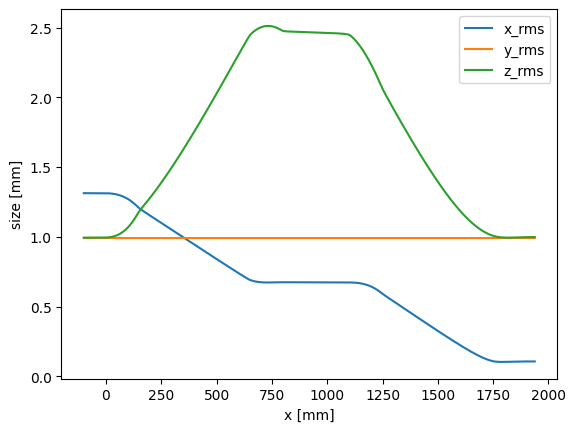

In [59]:
plt.plot(1e3*x, 1e3*x_rms, label="x_rms")
plt.plot(1e3*x, 1e3*y_rms, label="y_rms")
plt.plot(1e3*x, 1e3*z_rms, label="z_rms")
plt.xlabel('x [mm]')
plt.ylabel('size [mm]')
plt.legend()
plt.show()

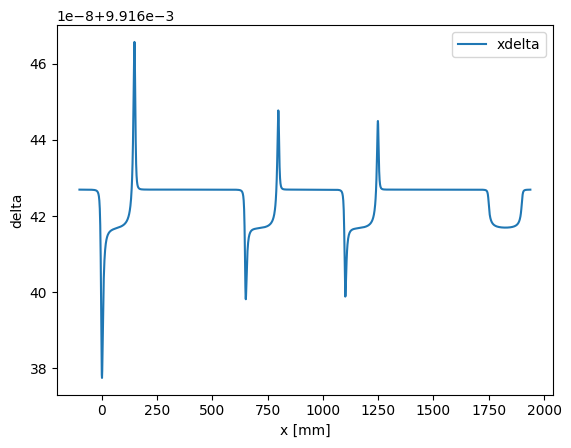

In [60]:
plt.plot(1e3*x, delta, label="delta")
plt.xlabel('x [mm]')
plt.ylabel('delta')
plt.legend()
plt.show()

reading  chicane_beam_start.h5
have read 10000 particles.
{'N': 10000, 'x_mean': -0.09997441951080996, 'y_mean': 9.483649466288812e-07, 'z_mean': 4.692335040444829e-06, 'xp_mean': 1.570796326794897, 'yp_mean': 0.0, 'bgx_mean': 46.94687731555874, 'bgy_mean': 0.0, 'bgz_mean': 0.0, 'E_kin': 23484248.292057145, 'E_tot': 23995247.242053308, 'gamma': 46.95752749048394, 'betagamma': 46.94687731555874, 'x_rms': 0.0013127072454423123, 'y_rms': 0.0009909085612461288, 'z_rms': 0.0009940451598946685, 't_rms': 3.315777743463675e-12, 'E_rms': 237839.17305658504, 'ex_n_rms': 2.7368110445913493e-17, 'ey_n_rms': 0.0, 'ez_rms': 7.884103982815301e-07}


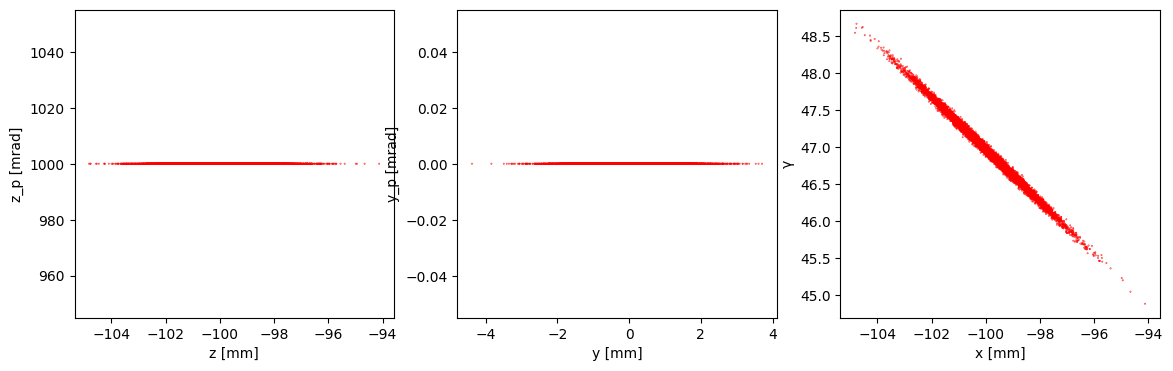

In [64]:
watch = teufel.TeufelWatch.read('chicane_beam_start.h5')
print(watch.parameters())

fig1, ((ax1, ax2, ax3)) = plt.subplots(figsize=(14,4), nrows=1, ncols=3)
ones = np.ones(watch.NOP)
bg = np.sqrt(watch.bgx**2+watch.bgy**2+watch.bgz**2)
ax1.scatter(1e3*watch.x, 1e3*watch.bgx/bg, 0.1*ones, color='r')
ax1.set_xlabel('z [mm]')
ax1.set_ylabel('z_p [mrad]')
ax2.scatter(1e3*watch.y, 1e3*watch.bgy/bg, 0.1*ones, color='r')
ax2.set_xlabel('y [mm]')
ax2.set_ylabel('y_p [mrad]')
ax3.scatter(1e3*watch.x, watch.gamma, 0.1*ones, color='r')
ax3.set_xlabel('x [mm]')
ax3.set_ylabel('γ')
plt.show()

reading  chicane_beam_final.h5
have read 10000 particles.
{'N': 10000, 'x_mean': 1.9379462055098862, 'y_mean': 9.483649466288812e-07, 'z_mean': -0.004967629994242418, 'xp_mean': 1.577641229936653, 'yp_mean': 3.141592653589794, 'bgx_mean': 46.94577764305615, 'bgy_mean': 0.0, 'bgz_mean': -0.32130063127974756, 'E_kin': 23484248.305077806, 'E_tot': 23995247.25507397, 'gamma': 46.957527515964735, 'betagamma': 46.94687734104531, 'x_rms': 0.00010617670361108824, 'y_rms': 0.0009909085612461288, 'z_rms': 0.0009980563033488035, 't_rms': 3.32915747783356e-12, 'E_rms': 237839.17295712393, 'ex_n_rms': 4.607560090438463e-07, 'ey_n_rms': 4.131811575637351e-17, 'ez_rms': 7.884278112153364e-07}


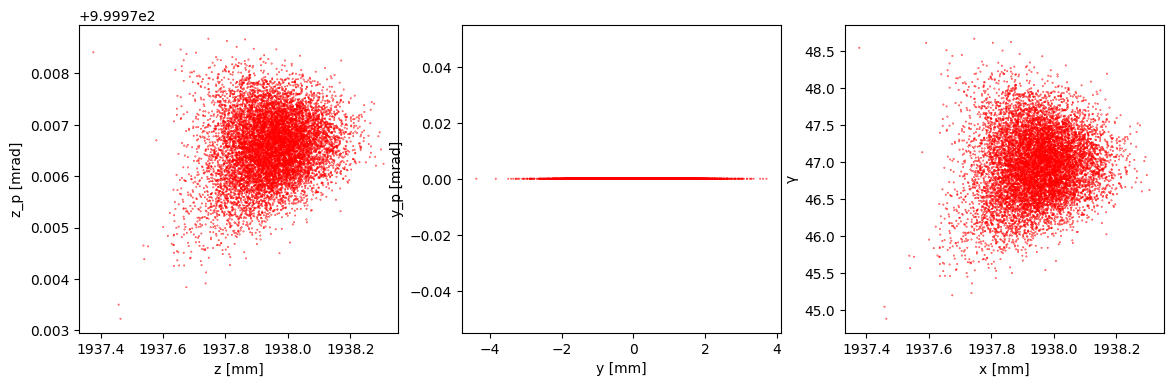

In [63]:
watch = teufel.TeufelWatch.read('chicane_beam_final.h5')
print(watch.parameters())

fig1, ((ax1, ax2, ax3)) = plt.subplots(figsize=(14,4), nrows=1, ncols=3)
ones = np.ones(watch.NOP)
bg = np.sqrt(watch.bgx**2+watch.bgy**2+watch.bgz**2)
ax1.scatter(1e3*watch.x, 1e3*watch.bgx/bg, 0.1*ones, color='r')
ax1.set_xlabel('z [mm]')
ax1.set_ylabel('z_p [mrad]')
ax2.scatter(1e3*watch.y, 1e3*watch.bgy/bg, 0.1*ones, color='r')
ax2.set_xlabel('y [mm]')
ax2.set_ylabel('y_p [mrad]')
ax3.scatter(1e3*watch.x, watch.gamma, 0.1*ones, color='r')
ax3.set_xlabel('x [mm]')
ax3.set_ylabel('γ')
plt.show()